# HPRC Ensembl vs CAT Annotation QC Report

This notebook generates a comprehensive QC report comparing Ensembl (linear projection) and CAT (graph-based projection) gene annotations across 400+ HPRC assemblies.

**Memory-efficient design**: Processes data in chunks, computes summaries, and saves to disk immediately.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import gc
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Pandas version: 3.0.1
NumPy version: 2.4.2


## Configuration

In [2]:
# Set paths
OUTPUT_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')  # Adjust this path as needed
QC_DIR = OUTPUT_DIR / 'qc_metrics'
RESULTS_DIR = OUTPUT_DIR / 'results'
SUMMARY_DIR = OUTPUT_DIR / 'summary_stats'  # Where we'll save intermediate results
SUMMARY_DIR.mkdir(exist_ok=True, parents=True)

# Processing parameters
CHUNK_SIZE = 50  # Process 50 assemblies at a time

print(f"Output directory: {OUTPUT_DIR}")
print(f"QC metrics directory: {QC_DIR}")
print(f"Summary stats directory: {SUMMARY_DIR}")
print(f"Chunk size: {CHUNK_SIZE} assemblies")

Output directory: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results
QC metrics directory: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics
Summary stats directory: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/summary_stats
Chunk size: 50 assemblies


## Gencode Version Filtering (Optional)

CAT and Ensembl may have used different Gencode versions as their reference. To enable fair comparison, we can filter to "stable" genes/transcripts that exist in both versions.

**To enable this filtering:**
1. Set the paths to the Gencode GTF files used by each annotation method
2. Run the cells below to create stable gene sets
3. Filtered analyses will be generated alongside the full analyses

In [3]:
# Gencode version configuration
# Set these paths to enable Gencode version filtering
# Leave as None to skip filtering

GENCODE_CAT_GTF = None  # e.g., Path('/path/to/gencode.v47.annotation.gtf.gz')
GENCODE_ENSEMBL_GTF = None  # e.g., Path('/path/to/gencode.v44.annotation.gtf.gz')

# Enable filtering only if both paths are provided
ENABLE_GENCODE_FILTERING = GENCODE_CAT_GTF is not None and GENCODE_ENSEMBL_GTF is not None

if ENABLE_GENCODE_FILTERING:
    print(f"Gencode filtering ENABLED")
    print(f"  CAT Gencode: {GENCODE_CAT_GTF}")
    print(f"  Ensembl Gencode: {GENCODE_ENSEMBL_GTF}")
else:
    print("Gencode filtering DISABLED (set GENCODE_CAT_GTF and GENCODE_ENSEMBL_GTF to enable)")

Gencode filtering DISABLED (set GENCODE_CAT_GTF and GENCODE_ENSEMBL_GTF to enable)


In [4]:
import gzip
from collections import defaultdict

def parse_gencode_gtf(gtf_path):
    """
    Parse a Gencode GTF file and extract gene/transcript information.
    
    Returns:
        genes: dict {gene_id: {'name': str, 'biotype': str, 'chrom': str}}
        transcripts: dict {transcript_id: {'gene_id': str, 'exons': [(start, end), ...]}}
    """
    genes = {}
    transcripts = defaultdict(lambda: {'gene_id': None, 'exons': []})
    
    opener = gzip.open if str(gtf_path).endswith('.gz') else open
    
    with opener(gtf_path, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
            
            chrom, source, feature, start, end, score, strand, frame, attrs = parts
            
            # Parse attributes
            attr_dict = {}
            for attr in attrs.split(';'):
                attr = attr.strip()
                if ' ' in attr:
                    key, val = attr.split(' ', 1)
                    attr_dict[key] = val.strip('"')
            
            gene_id = attr_dict.get('gene_id', '').split('.')[0]  # Remove version
            
            if feature == 'gene':
                genes[gene_id] = {
                    'name': attr_dict.get('gene_name', ''),
                    'biotype': attr_dict.get('gene_type', attr_dict.get('gene_biotype', '')),
                    'chrom': chrom
                }
            
            elif feature == 'transcript':
                tx_id = attr_dict.get('transcript_id', '').split('.')[0]
                transcripts[tx_id]['gene_id'] = gene_id
            
            elif feature == 'exon':
                tx_id = attr_dict.get('transcript_id', '').split('.')[0]
                transcripts[tx_id]['exons'].append((int(start), int(end)))
    
    # Sort exons for each transcript
    for tx_id in transcripts:
        transcripts[tx_id]['exons'].sort()
    
    return genes, dict(transcripts)


def create_stable_gene_set(genes_v1, genes_v2):
    """
    Create a set of gene IDs present in both Gencode versions.
    """
    return set(genes_v1.keys()) & set(genes_v2.keys())


def create_stable_transcript_set(tx_v1, tx_v2):
    """
    Create a set of transcript IDs with identical exon structure in both versions.
    """
    stable = set()
    
    common_tx = set(tx_v1.keys()) & set(tx_v2.keys())
    
    for tx_id in common_tx:
        exons_1 = tuple(tx_v1[tx_id]['exons'])
        exons_2 = tuple(tx_v2[tx_id]['exons'])
        
        if exons_1 == exons_2:
            stable.add(tx_id)
    
    return stable


# Load Gencode data if filtering is enabled
stable_genes = None
stable_transcripts = None

if ENABLE_GENCODE_FILTERING:
    print("Loading Gencode GTF files...")
    
    print(f"  Parsing CAT Gencode: {GENCODE_CAT_GTF}")
    cat_genes, cat_transcripts = parse_gencode_gtf(GENCODE_CAT_GTF)
    print(f"    Found {len(cat_genes):,} genes, {len(cat_transcripts):,} transcripts")
    
    print(f"  Parsing Ensembl Gencode: {GENCODE_ENSEMBL_GTF}")
    ens_genes, ens_transcripts = parse_gencode_gtf(GENCODE_ENSEMBL_GTF)
    print(f"    Found {len(ens_genes):,} genes, {len(ens_transcripts):,} transcripts")
    
    print("\nCreating stable sets...")
    stable_genes = create_stable_gene_set(cat_genes, ens_genes)
    print(f"  Stable genes (in both versions): {len(stable_genes):,}")
    
    stable_transcripts = create_stable_transcript_set(cat_transcripts, ens_transcripts)
    print(f"  Stable transcripts (identical exons): {len(stable_transcripts):,}")
    
    # Save stable sets for reference
    pd.DataFrame({'gene_id': list(stable_genes)}).to_csv(
        SUMMARY_DIR / 'stable_genes.tsv', sep='\t', index=False
    )
    pd.DataFrame({'transcript_id': list(stable_transcripts)}).to_csv(
        SUMMARY_DIR / 'stable_transcripts.tsv', sep='\t', index=False
    )
    print(f"\n✓ Stable sets saved to {SUMMARY_DIR}")
    
    # Clean up memory
    del cat_genes, cat_transcripts, ens_genes, ens_transcripts
    gc.collect()
else:
    print("Skipping Gencode filtering (not configured)")

Skipping Gencode filtering (not configured)


In [5]:
def filter_to_stable_genes(df, gene_id_col='ensembl_gene_id', stable_set=None):
    """
    Filter a DataFrame to only include rows where the gene is in the stable set.
    
    Args:
        df: DataFrame with gene IDs
        gene_id_col: Column name containing gene IDs (will strip version suffix)
        stable_set: Set of stable gene IDs (without version)
    
    Returns:
        Filtered DataFrame
    """
    if stable_set is None:
        return df
    
    # Strip version suffix from gene IDs for matching
    gene_ids_stripped = df[gene_id_col].str.split('.').str[0]
    mask = gene_ids_stripped.isin(stable_set)
    
    return df[mask].copy()


def compute_filtered_stats(description, df_full, df_filtered, metric_col=None):
    """
    Print comparison statistics between full and filtered datasets.
    """
    n_full = len(df_full)
    n_filtered = len(df_filtered)
    pct_retained = n_filtered / n_full * 100 if n_full > 0 else 0
    
    print(f"\n{description}:")
    print(f"  Full dataset: {n_full:,} records")
    print(f"  Stable genes only: {n_filtered:,} records ({pct_retained:.1f}% retained)")
    
    if metric_col and metric_col in df_full.columns:
        mean_full = df_full[metric_col].mean()
        mean_filt = df_filtered[metric_col].mean() if len(df_filtered) > 0 else 0
        print(f"  Mean {metric_col}: {mean_full:.3f} (full) vs {mean_filt:.3f} (stable)")

print("✓ Filtering helper functions defined")

✓ Filtering helper functions defined


## 1. Process Transcript Concordance (Chunked)

Process files in chunks to avoid memory issues.

In [6]:
def process_transcript_concordance_chunked():
    """Process transcript concordance in chunks and save summary stats."""
    files = list(QC_DIR.rglob('*_transcript_concordance.tsv'))
    print(f"Found {len(files)} transcript concordance files")
    
    if not files:
        return None
    
    # Process in chunks
    per_assembly_stats = []
    concordance_rates = []
    jaccard_indices = []
    
    for i in range(0, len(files), CHUNK_SIZE):
        chunk_files = files[i:i+CHUNK_SIZE]
        print(f"Processing chunk {i//CHUNK_SIZE + 1}/{(len(files)-1)//CHUNK_SIZE + 1} ({len(chunk_files)} files)")
        
        chunk_dfs = []
        for f in chunk_files:
            try:
                df = pd.read_csv(f, sep='\t')
                chunk_dfs.append(df)
            except Exception as e:
                print(f"Error loading {f}: {e}")
        
        if chunk_dfs:
            chunk_data = pd.concat(chunk_dfs, ignore_index=True)
            
            # Extract rates for overall distribution
            concordance_rates.extend(chunk_data['transcript_concordance_rate'].tolist())
            if 'avg_jaccard_index' in chunk_data.columns:
                jaccard_indices.extend(chunk_data['avg_jaccard_index'].tolist())
            
            # Per-assembly summary
            agg_dict = {
                'transcript_concordance_rate': 'mean',
                'n_ens_exact': 'sum',
                'n_ens_unmatched': 'sum',
                'ensembl_gene_id': 'count'
            }

            # Add columns if present
            for col in ['avg_jaccard_index', 'n_ens_intron_match', 'n_ens_subset',
                       'n_ens_superset', 'n_ens_partial_5', 'n_ens_partial_3', 'n_ens_other_partial']:
                if col in chunk_data.columns:
                    agg_dict[col] = 'mean' if 'index' in col else 'sum'
            
            assembly_summary = chunk_data.groupby('assembly_accession').agg(agg_dict).reset_index()
            per_assembly_stats.append(assembly_summary)
            
            del chunk_data, chunk_dfs
            gc.collect()
    
    # Combine and save per-assembly stats
    if per_assembly_stats:
        per_assembly_df = pd.concat(per_assembly_stats, ignore_index=True)
        per_assembly_df.to_csv(SUMMARY_DIR / 'transcript_concordance_per_assembly.tsv', 
                               sep='\t', index=False)
        print(f"Saved per-assembly stats: {len(per_assembly_df)} assemblies")
    
    # Save concordance rate distribution
    concordance_df = pd.DataFrame({'concordance_rate': concordance_rates})
    concordance_df.to_csv(SUMMARY_DIR / 'transcript_concordance_rates.tsv', 
                          sep='\t', index=False)
                          
    if jaccard_indices:
        pd.DataFrame({'jaccard_index': jaccard_indices}).to_csv(
            SUMMARY_DIR / 'transcript_jaccard_indices.tsv', sep='\t', index=False
        )
    
    print(f"Saved concordance rates: {len(concordance_rates)} gene pairs")
    
    del concordance_rates, per_assembly_stats, jaccard_indices
    gc.collect()
    
    return per_assembly_df

transcript_summary = process_transcript_concordance_chunked()
print("\n✓ Transcript concordance processing complete")

Found 462 transcript concordance files
Processing chunk 1/10 (50 files)
Processing chunk 2/10 (50 files)
Processing chunk 3/10 (50 files)
Processing chunk 4/10 (50 files)
Processing chunk 5/10 (50 files)
Processing chunk 6/10 (50 files)
Processing chunk 7/10 (50 files)
Processing chunk 8/10 (50 files)
Processing chunk 9/10 (50 files)
Processing chunk 10/10 (12 files)
Saved per-assembly stats: 462 assemblies
Saved concordance rates: 34752712 gene pairs

✓ Transcript concordance processing complete


## 2. Process Coding Integrity (Chunked)

In [7]:
def process_coding_integrity_chunked():
    """Process coding integrity in chunks and save summary stats."""
    files = list(QC_DIR.rglob('*_coding_integrity.tsv'))
    print(f"Found {len(files)} coding integrity files")
    
    if not files:
        return None
    
    # Accumulators
    total_genes = 0
    genes_with_cds = 0
    start_matches = 0
    stop_matches = 0
    both_matches = 0
    frameshifts = 0
    classification_counts = {}
    length_diffs = []
    per_assembly_stats = []
    
    for i in range(0, len(files), CHUNK_SIZE):
        chunk_files = files[i:i+CHUNK_SIZE]
        print(f"Processing chunk {i//CHUNK_SIZE + 1}/{(len(files)-1)//CHUNK_SIZE + 1}")
        
        chunk_dfs = []
        for f in chunk_files:
            try:
                df = pd.read_csv(f, sep='\t')
                # Convert boolean strings
                for col in ['start_codon_match', 'stop_codon_match', 'frameshift_detected', 
                           'has_ensembl_cds', 'has_cat_cds']:
                    if col in df.columns:
                        df[col] = df[col].map({'True': True, 'False': False, True: True, False: False})
                chunk_dfs.append(df)
            except Exception as e:
                print(f"Error loading {f}: {e}")
        
        if chunk_dfs:
            chunk_data = pd.concat(chunk_dfs, ignore_index=True)
            
            # Filter to genes with CDS in both
            with_cds = chunk_data[
                (chunk_data['has_ensembl_cds'] == True) & 
                (chunk_data['has_cat_cds'] == True)
            ]
            
            # Accumulate basic stats
            total_genes += len(chunk_data)
            genes_with_cds += len(with_cds)
            
            if len(with_cds) > 0:
                start_matches += (with_cds['start_codon_match'] == True).sum()
                stop_matches += (with_cds['stop_codon_match'] == True).sum()
                both_matches += ((with_cds['start_codon_match'] == True) & 
                                (with_cds['stop_codon_match'] == True)).sum()
                frameshifts += (with_cds['frameshift_detected'] == True).sum()
                
                # Accumulate classifications
                if 'classification' in with_cds.columns:
                    for cls, count in with_cds['classification'].value_counts().items():
                        classification_counts[cls] = classification_counts.get(cls, 0) + count
                
                # Sample length differences
                length_diffs.extend(with_cds['length_difference'].sample(
                    min(1000, len(with_cds))
                ).tolist())
                
                # Per-assembly stats
                assembly_stats = with_cds.groupby('assembly_accession').apply(
                    lambda x: pd.Series({
                        'n_protein_coding': len(x),
                        'start_stop_agreement': ((x['start_codon_match'] == True) & 
                                                (x['stop_codon_match'] == True)).sum() / len(x),
                        'n_frameshifts': (x['frameshift_detected'] == True).sum(),
                        'n_full_match': (x['classification'] == 'Full_Match').sum() if 'classification' in x.columns else 0
                    })
                ).reset_index()
                per_assembly_stats.append(assembly_stats)
            
            del chunk_data, chunk_dfs, with_cds
            gc.collect()
    
    # Save overall stats
    overall_data = {
        'total_genes': total_genes,
        'genes_with_cds_both': genes_with_cds,
        'start_codon_matches': start_matches,
        'stop_codon_matches': stop_matches,
        'both_codons_match': both_matches,
        'frameshifts_detected': frameshifts,
        'pct_with_cds': genes_with_cds / total_genes if total_genes > 0 else 0,
        'pct_start_match': start_matches / genes_with_cds if genes_with_cds > 0 else 0,
        'pct_stop_match': stop_matches / genes_with_cds if genes_with_cds > 0 else 0,
        'pct_both_match': both_matches / genes_with_cds if genes_with_cds > 0 else 0,
        'pct_frameshift': frameshifts / genes_with_cds if genes_with_cds > 0 else 0
    }
    overall_stats = pd.DataFrame([overall_data])
    overall_stats.to_csv(SUMMARY_DIR / 'coding_integrity_overall.tsv', sep='\t', index=False)
    
    # Save classification counts
    pd.DataFrame([
        {'classification': k, 'count': v, 'percentage': v/genes_with_cds if genes_with_cds > 0 else 0}
        for k, v in classification_counts.items()
    ]).to_csv(SUMMARY_DIR / 'coding_classifications.tsv', sep='\t', index=False)
    
    # Save length differences sample
    pd.DataFrame({'length_difference': length_diffs}).to_csv(
        SUMMARY_DIR / 'cds_length_differences_sample.tsv', sep='\t', index=False
    )
    
    # Save per-assembly stats
    if per_assembly_stats:
        per_assembly_df = pd.concat(per_assembly_stats, ignore_index=True)
        per_assembly_df.to_csv(SUMMARY_DIR / 'coding_integrity_per_assembly.tsv', 
                               sep='\t', index=False)
    
    print(f"Saved coding integrity stats: {total_genes} total genes, {genes_with_cds} with CDS")
    
    return overall_stats

coding_summary = process_coding_integrity_chunked()
print("\n✓ Coding integrity processing complete")

Found 462 coding integrity files
Processing chunk 1/10
Processing chunk 2/10
Processing chunk 3/10
Processing chunk 4/10
Processing chunk 5/10
Processing chunk 6/10
Processing chunk 7/10
Processing chunk 8/10
Processing chunk 9/10
Processing chunk 10/10
Saved coding integrity stats: 8651534 total genes, 8609940 with CDS

✓ Coding integrity processing complete


## 3. Process Gene Presence/Absence (Chunked)

In [8]:
def process_gene_presence_chunked():
    """Process gene presence in chunks and save summary stats."""
    files = list(QC_DIR.rglob('*_gene_presence.tsv'))
    print(f"Found {len(files)} gene presence files")
    
    if not files:
        return None
    
    # Count genes across all assemblies
    gene_counts = {'both': 0, 'ensembl_only': 0, 'cat_only': 0}
    ensembl_missing_genes = {}
    cat_missing_genes = {}
    
    for i in range(0, len(files), CHUNK_SIZE):
        chunk_files = files[i:i+CHUNK_SIZE]
        print(f"Processing chunk {i//CHUNK_SIZE + 1}/{(len(files)-1)//CHUNK_SIZE + 1}")
        
        chunk_dfs = []
        for f in chunk_files:
            try:
                df = pd.read_csv(f, sep='\t')
                # Convert boolean strings
                df['present_in_ensembl'] = df['present_in_ensembl'].map(
                    {'True': True, 'False': False, True: True, False: False}
                )
                df['present_in_cat'] = df['present_in_cat'].map(
                    {'True': True, 'False': False, True: True, False: False}
                )
                chunk_dfs.append(df)
            except Exception as e:
                print(f"Error loading {f}: {e}")
        
        if chunk_dfs:
            chunk_data = pd.concat(chunk_dfs, ignore_index=True)

            # Exclude bare Ensembl stable IDs (genes without a display name assigned)
            chunk_data = chunk_data[~chunk_data['gene_name'].str.match(r'^ENSG', na=False)]

            # Count by category
            both = ((chunk_data['present_in_ensembl'] == True) & 
                   (chunk_data['present_in_cat'] == True)).sum()
            ens_only = ((chunk_data['present_in_ensembl'] == True) & 
                       (chunk_data['present_in_cat'] == False)).sum()
            cat_only = ((chunk_data['present_in_ensembl'] == False) & 
                       (chunk_data['present_in_cat'] == True)).sum()
            
            gene_counts['both'] += both
            gene_counts['ensembl_only'] += ens_only
            gene_counts['cat_only'] += cat_only
            
            # Track top missing genes
            ens_missing = chunk_data[
                (chunk_data['present_in_ensembl'] == True) & 
                (chunk_data['present_in_cat'] == False)
            ]
            for gene in ens_missing['gene_name'].value_counts().head(50).index:
                ensembl_missing_genes[gene] = ensembl_missing_genes.get(gene, 0) + \
                    (ens_missing['gene_name'] == gene).sum()
            
            cat_missing = chunk_data[
                (chunk_data['present_in_ensembl'] == False) & 
                (chunk_data['present_in_cat'] == True)
            ]
            for gene in cat_missing['gene_name'].value_counts().head(50).index:
                cat_missing_genes[gene] = cat_missing_genes.get(gene, 0) + \
                    (cat_missing['gene_name'] == gene).sum()
            
            del chunk_data, chunk_dfs
            gc.collect()
    
    # Save summary
    summary = pd.DataFrame([gene_counts])
    total = sum(gene_counts.values())
    summary['total'] = total
    summary['pct_both'] = gene_counts['both'] / total if total > 0 else 0
    summary['pct_ensembl_only'] = gene_counts['ensembl_only'] / total if total > 0 else 0
    summary['pct_cat_only'] = gene_counts['cat_only'] / total if total > 0 else 0
    summary.to_csv(SUMMARY_DIR / 'gene_presence_summary.tsv', sep='\t', index=False)
    
    # Save top missing genes
    pd.DataFrame([
        {'gene': k, 'n_assemblies': v, 'missing_from': 'CAT'} 
        for k, v in sorted(ensembl_missing_genes.items(), key=lambda x: -x[1])[:50]
    ] + [
        {'gene': k, 'n_assemblies': v, 'missing_from': 'Ensembl'} 
        for k, v in sorted(cat_missing_genes.items(), key=lambda x: -x[1])[:50]
    ]).to_csv(SUMMARY_DIR / 'top_missing_genes.tsv', sep='\t', index=False)
    
    print(f"Saved gene presence stats: {total} total occurrences")
    
    del ensembl_missing_genes, cat_missing_genes
    gc.collect()
    
    return summary

presence_summary = process_gene_presence_chunked()
print("\n✓ Gene presence processing complete")

Found 462 gene presence files
Processing chunk 1/10
Processing chunk 2/10
Processing chunk 3/10
Processing chunk 4/10
Processing chunk 5/10
Processing chunk 6/10
Processing chunk 7/10
Processing chunk 8/10
Processing chunk 9/10
Processing chunk 10/10
Saved gene presence stats: 18831748 total occurrences

✓ Gene presence processing complete


## 4. Process Multi-Mapping (Lightweight - just count)

In [9]:
def process_multi_mapping_chunked():
    """Process multi-mapping and save counts & classifications."""
    files = list(QC_DIR.rglob('*_multi_mapping.tsv'))
    print(f"Found {len(files)} multi-mapping files")
    
    if not files:
        return None
    
    ensembl_counts = []
    cat_counts = []
    ensembl_classifications = {}
    cat_classifications = {}
    
    for i in range(0, len(files), CHUNK_SIZE):
        chunk_files = files[i:i+CHUNK_SIZE]
        print(f"Processing chunk {i//CHUNK_SIZE + 1}/{(len(files)-1)//CHUNK_SIZE + 1}")
        
        for f in chunk_files:
            try:
                df = pd.read_csv(f, sep='\t')
                ensembl_multi = df[df['source'] == 'ensembl']
                cat_multi = df[df['source'] == 'cat']
                
                if len(ensembl_multi) > 0:
                    ensembl_counts.extend(ensembl_multi['n_matches'].tolist())
                    if 'classification' in ensembl_multi.columns:
                        for cls, count in ensembl_multi['classification'].value_counts().items():
                            ensembl_classifications[cls] = ensembl_classifications.get(cls, 0) + count
                            
                if len(cat_multi) > 0:
                    cat_counts.extend(cat_multi['n_matches'].tolist())
                    if 'classification' in cat_multi.columns:
                        for cls, count in cat_multi['classification'].value_counts().items():
                            cat_classifications[cls] = cat_classifications.get(cls, 0) + count
                    
            except Exception as e:
                print(f"Error loading {f}: {e}")
    
    # Save summary
    summary = pd.DataFrame([{
        'ensembl_genes_multi_mapped': len(ensembl_counts),
        'cat_genes_multi_mapped': len(cat_counts),
        'mean_ensembl_matches': np.mean(ensembl_counts) if ensembl_counts else 0,
        'mean_cat_matches': np.mean(cat_counts) if cat_counts else 0,
    }])
    summary.to_csv(SUMMARY_DIR / 'multi_mapping_summary.tsv', sep='\t', index=False)
    
    # Save classifications
    pd.DataFrame([
        {'source': 'ensembl', 'classification': k, 'count': v} for k, v in ensembl_classifications.items()
    ] + [
        {'source': 'cat', 'classification': k, 'count': v} for k, v in cat_classifications.items()
    ]).to_csv(SUMMARY_DIR / 'multi_mapping_classifications.tsv', sep='\t', index=False)
    
    print(f"Saved multi-mapping stats: {len(ensembl_counts)} Ensembl, {len(cat_counts)} CAT")
    
    return summary

multi_summary = process_multi_mapping_chunked()
print("\n✓ Multi-mapping processing complete")

Found 462 multi-mapping files
Processing chunk 1/10
Processing chunk 2/10
Processing chunk 3/10
Processing chunk 4/10
Processing chunk 5/10
Processing chunk 6/10
Processing chunk 7/10
Processing chunk 8/10
Processing chunk 9/10
Processing chunk 10/10
Saved multi-mapping stats: 24256519 Ensembl, 23808768 CAT

✓ Multi-mapping processing complete


## 5. Process RBH Pairs (Sample for visualization)

In [10]:
def process_rbh_pairs_chunked():
    """Process RBH pairs and save statistics + sample for plotting."""
    files = list(RESULTS_DIR.rglob('*.gene_pairs_rbh.tsv'))
    print(f"Found {len(files)} RBH files")

    if not files:
        return None

    total_pairs = 0
    detailed_counts = {}   # classification_detailed breakdown
    coverage_sample = []
    SAMPLE_SIZE = 10000

    for i in range(0, len(files), CHUNK_SIZE):
        chunk_files = files[i:i+CHUNK_SIZE]
        print(f"Processing chunk {i//CHUNK_SIZE + 1}/{(len(files)-1)//CHUNK_SIZE + 1}")

        chunk_dfs = []
        for f in chunk_files:
            try:
                df = pd.read_csv(f, sep='\t')
                chunk_dfs.append(df)
            except Exception as e:
                print(f"Error loading {f}: {e}")

        if chunk_dfs:
            chunk_data = pd.concat(chunk_dfs, ignore_index=True)

            total_pairs += len(chunk_data)

            # Use classification_detailed (finer-grained than legacy classification)
            cls_col = 'classification_detailed' if 'classification_detailed' in chunk_data.columns else 'classification'
            for cls, count in chunk_data[cls_col].value_counts().items():
                detailed_counts[cls] = detailed_counts.get(cls, 0) + count

            # Sample for scatter plot
            if len(coverage_sample) < SAMPLE_SIZE:
                sample = chunk_data[['frac_ensembl_covered', 'frac_cat_covered']].sample(
                    min(SAMPLE_SIZE - len(coverage_sample), len(chunk_data))
                )
                coverage_sample.append(sample)

            del chunk_data, chunk_dfs
            gc.collect()

    # Identical + Near-identical as the "high concordance" summary stat
    # (replaces old >=90% threshold which conflated three tiers)
    high_concordance_cats = {'Identical', 'Near-identical'}
    high_count = sum(v for k, v in detailed_counts.items() if k in high_concordance_cats)

    summary = pd.DataFrame([{
        'total_rbh_pairs': total_pairs,
        'high_concordance_pairs': high_count,
        'pct_high_concordance': high_count / total_pairs if total_pairs > 0 else 0,
    }])
    summary.to_csv(SUMMARY_DIR / 'rbh_pairs_summary.tsv', sep='\t', index=False)

    pd.DataFrame([
        {'classification': k, 'count': v, 'percentage': v / total_pairs if total_pairs > 0 else 0}
        for k, v in detailed_counts.items()
    ]).to_csv(SUMMARY_DIR / 'rbh_classifications.tsv', sep='\t', index=False)

    if coverage_sample:
        pd.concat(coverage_sample, ignore_index=True).to_csv(
            SUMMARY_DIR / 'rbh_coverage_sample.tsv', sep='\t', index=False
        )

    print(f"Saved RBH stats: {total_pairs} total pairs")
    del coverage_sample, detailed_counts
    gc.collect()
    return summary

rbh_summary = process_rbh_pairs_chunked()
print("\n✓ RBH pairs processing complete")

Found 462 RBH files
Processing chunk 1/10
Processing chunk 2/10
Processing chunk 3/10
Processing chunk 4/10
Processing chunk 5/10
Processing chunk 6/10
Processing chunk 7/10
Processing chunk 8/10
Processing chunk 9/10
Processing chunk 10/10
Saved RBH stats: 34752712 total pairs

✓ RBH pairs processing complete


## 6. Generate Visualizations from Saved Data

Now load only the small summary files and generate plots.

In [11]:
print("\n" + "="*80)
print("GENERATING SUMMARY REPORT")
print("="*80 + "\n")

# Load summary data (small files)
concordance_rates = pd.read_csv(SUMMARY_DIR / 'transcript_concordance_rates.tsv', sep='\t')
coding_overall = pd.read_csv(SUMMARY_DIR / 'coding_integrity_overall.tsv', sep='\t')
presence_summary = pd.read_csv(SUMMARY_DIR / 'gene_presence_summary.tsv', sep='\t')
multi_summary = pd.read_csv(SUMMARY_DIR / 'multi_mapping_summary.tsv', sep='\t')
rbh_summary = pd.read_csv(SUMMARY_DIR / 'rbh_pairs_summary.tsv', sep='\t')

print("Summary Statistics:")
print(f"  Total RBH pairs analyzed: {rbh_summary['total_rbh_pairs'].iloc[0]:,}")
print(f"  Gene pairs with transcript data: {len(concordance_rates):,}")
print(f"  Mean transcript concordance: {concordance_rates['concordance_rate'].mean():.2%}")
print(f"  Protein-coding genes with CDS: {coding_overall['genes_with_cds_both'].iloc[0]:,}")
print(f"  Start & stop codon agreement: {coding_overall['pct_both_match'].iloc[0]:.1%}")
print(f"  Multi-mapped Ensembl genes: {multi_summary['ensembl_genes_multi_mapped'].iloc[0]:,}")
print(f"  Multi-mapped CAT genes: {multi_summary['cat_genes_multi_mapped'].iloc[0]:,}")


GENERATING SUMMARY REPORT

Summary Statistics:
  Total RBH pairs analyzed: 34,752,712
  Gene pairs with transcript data: 34,752,712
  Mean transcript concordance: 93.91%
  Protein-coding genes with CDS: 8,609,940
  Start & stop codon agreement: 98.2%
  Multi-mapped Ensembl genes: 24,256,519
  Multi-mapped CAT genes: 23,808,768


### 6.1 Transcript Concordance Plots

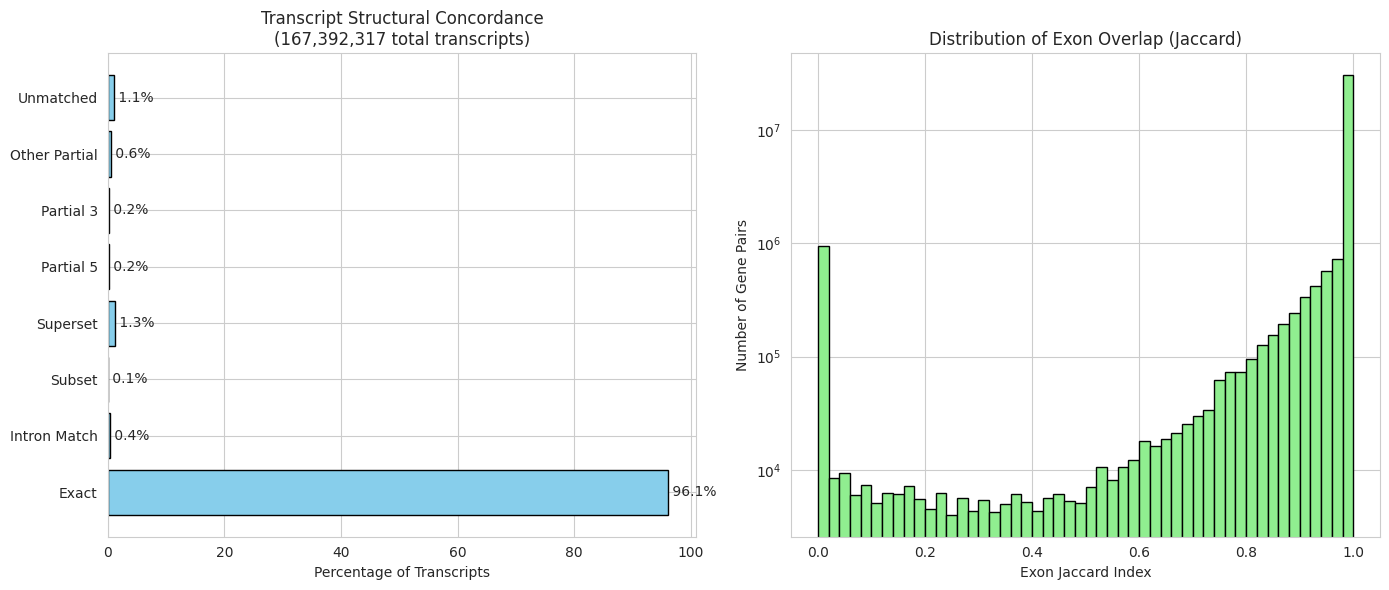

✓ Saved transcript_concordance_detailed.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Breakdown of Match Types (Overall)
# We need to sum the counts from the per-assembly stats
per_assembly = pd.read_csv(SUMMARY_DIR / 'transcript_concordance_per_assembly.tsv', sep='\t')
cols = ['n_ens_exact', 'n_ens_intron_match', 'n_ens_subset', 'n_ens_superset',
        'n_ens_partial_5', 'n_ens_partial_3', 'n_ens_other_partial', 'n_ens_unmatched']
counts = [per_assembly[c].sum() for c in cols if c in per_assembly.columns]
labels = [c.replace('n_ens_', '').replace('_', ' ').title() for c in cols if c in per_assembly.columns]

total = sum(counts)
pcts = [c/total*100 for c in counts]

axes[0].barh(labels, pcts, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Percentage of Transcripts')
axes[0].set_title(f'Transcript Structural Concordance\n({total:,} total transcripts)')
for i, v in enumerate(pcts):
    axes[0].text(v, i, f' {v:.1f}%', va='center')

# Plot 2: Jaccard Index Distribution
if (SUMMARY_DIR / 'transcript_jaccard_indices.tsv').exists():
    jaccard = pd.read_csv(SUMMARY_DIR / 'transcript_jaccard_indices.tsv', sep='\t')
    axes[1].hist(jaccard['jaccard_index'], bins=50, edgecolor='black', color='lightgreen')
    axes[1].set_xlabel('Exon Jaccard Index')
    axes[1].set_ylabel('Number of Gene Pairs')
    axes[1].set_title('Distribution of Exon Overlap (Jaccard)')
    axes[1].set_yscale('log')
else:
    axes[1].text(0.5, 0.5, 'Jaccard data not available', ha='center')

plt.tight_layout()
plt.savefig('figures/transcript_concordance_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved transcript_concordance_detailed.png")

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- config ----
CAT_COLS = [
    'n_ens_exact',
    'n_ens_intron_match',
    'n_ens_subset',
    'n_ens_superset',
    'n_ens_partial_5',
    'n_ens_partial_3',
    'n_ens_other_partial',
    'n_ens_unmatched',
]

CAT_ORDER = CAT_COLS[:]  # keep this order in the plot

CAT_LABELS = {
    'n_ens_exact': 'Exact',
    'n_ens_intron_match': 'Intron match',
    'n_ens_subset': 'Subset',
    'n_ens_superset': 'Superset',
    'n_ens_partial_5': 'Partial 5′',
    'n_ens_partial_3': 'Partial 3′',
    'n_ens_other_partial': 'Other partial',
    'n_ens_unmatched': 'Unmatched',
}

# Pick colors you like; these are placeholders
CAT_COLORS = {
    'n_ens_exact': '#8ecae6',
    'n_ens_intron_match': '#219ebc',
    'n_ens_subset': '#ffb703',
    'n_ens_superset': '#fb8500',
    'n_ens_partial_5': '#90be6d',
    'n_ens_partial_3': '#43aa8b',
    'n_ens_other_partial': '#577590',
    'n_ens_unmatched': '#e63946',
}

BIOTYPE_ORDER = ['protein_coding', 'lncRNA', 'pseudogene', 'other_ncRNA', 'other']
BIOTYPE_LABELS = {
    'protein_coding': 'Protein-coding',
    'lncRNA': 'lncRNA',
    'pseudogene': 'Pseudogene',
    'other_ncRNA': 'Other ncRNA',
    'other': 'Other',
}

# ---- load & aggregate ----
per_assembly = pd.read_csv(SUMMARY_DIR / 'transcript_concordance_per_assembly.tsv', sep='\t')

# change this if your column name is different
BIOTYPE_COL = 'biotype_group'

missing = [c for c in CAT_COLS if c not in per_assembly.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

if BIOTYPE_COL not in per_assembly.columns:
    raise ValueError(f"Missing biotype column '{BIOTYPE_COL}' in per-assembly TSV")

ct = (
    per_assembly
    .groupby(BIOTYPE_COL, dropna=False)[CAT_COLS]
    .sum()
    .reindex(BIOTYPE_ORDER)
    .fillna(0)
)

ValueError: Missing biotype column 'biotype_group' in per-assembly TSV

In [ ]:
def draw_biotype_transcript_concordance(ax, ct_counts, title, label_threshold_pct=6):
    """
    ct_counts: DataFrame index=biotype, columns=CAT_COLS with raw counts.
    Plots % within each biotype as stacked horizontal bars.
    """
    # Drop biotypes with no transcripts
    ct_counts = ct_counts.loc[ct_counts.sum(axis=1) > 0].copy()

    # Keep only present biotypes in your preferred order
    biotypes = [b for b in BIOTYPE_ORDER if b in ct_counts.index]
    y_pos = np.arange(len(biotypes))
    y_labels = [BIOTYPE_LABELS.get(b, b) for b in biotypes]

    # Convert to % within row
    row_totals = ct_counts.loc[biotypes].sum(axis=1).replace(0, np.nan)
    ct_pct = ct_counts.loc[biotypes].div(row_totals, axis=0) * 100
    ct_pct = ct_pct.fillna(0)

    # Only include categories that actually occur (avoid legend items with no marks)
    cats_present = [c for c in CAT_ORDER if c in ct_pct.columns and ct_counts[c].sum() > 0]

    left = np.zeros(len(biotypes), dtype=float)
    handles, labels = [], []

    for cat in cats_present:
        vals = ct_pct[cat].values
        bars = ax.barh(
            y_pos, vals, left=left,
            color=CAT_COLORS.get(cat, None),
            edgecolor='white', linewidth=0.6,
        )

        handles.append(bars[0])
        labels.append(CAT_LABELS.get(cat, cat))

        # Labels inside segments when wide enough
        for j, (v_pct, l) in enumerate(zip(vals, left)):
            if v_pct >= label_threshold_pct:
                raw = int(ct_counts.loc[biotypes[j], cat])
                ax.text(
                    l + v_pct / 2, j,
                    f'{v_pct:.1f}%\n({raw:,})',
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white'
                )

        left += vals

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Percentage of transcripts (within biotype)')
    ax.set_title(title)

    ax.legend(handles, labels, loc='lower right', framealpha=0.9, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_yaxis()  # protein-coding at top


fig, ax = plt.subplots(1, 1, figsize=(10, 5.5))
total_tx = int(ct.sum().sum())

draw_biotype_transcript_concordance(
    ax, ct,
    title=f'Transcript Structural Concordance by biotype\n({total_tx:,} total transcripts)'
)

plt.tight_layout()
plt.savefig('figures/transcript_concordance_by_biotype.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/transcript_concordance_by_biotype.pdf', bbox_inches='tight')
plt.show()
print("✓ Saved transcript_concordance_by_biotype.png/.pdf")

### 6.2 Coding Integrity Plots

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Classification Breakdown
if (SUMMARY_DIR / 'coding_classifications.tsv').exists():
    classifications = pd.read_csv(SUMMARY_DIR / 'coding_classifications.tsv', sep='\t')
    classifications = classifications.sort_values('count', ascending=True)
    
    axes[0].barh(classifications['classification'], classifications['percentage']*100, color='coral', edgecolor='black')
    axes[0].set_xlabel('Percentage of Genes')
    axes[0].set_title('Coding Integrity Classification')
    for i, row in classifications.iterrows():
        idx = list(classifications.index).index(i)
        axes[0].text(row['percentage']*100, idx, f" {row['percentage']*100:.1f}%", va='center')
else:
    axes[0].text(0.5, 0.5, 'Classification data not available', ha='center')

# Plot 2: CDS length differences (Log Scale)
length_diffs = pd.read_csv(SUMMARY_DIR / 'cds_length_differences_sample.tsv', sep='\t')
axes[1].hist(length_diffs['length_difference'], bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Absolute CDS Length Difference (bp)')
axes[1].set_ylabel('Number of Genes (Log Scale)')
axes[1].set_title(f'CDS Length Differences\n(Sample of {len(length_diffs):,} genes)')

plt.tight_layout()
plt.savefig('figures/coding_integrity_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved coding_integrity_detailed.png")

### 6.3 Gene Presence/Absence & Multi-Mapping

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Gene presence/absence (Keep existing)
presence = presence_summary.iloc[0]
categories = ['Both\nAnnotations', 'Ensembl\nOnly', 'CAT\nOnly']
counts = [presence['both'], presence['ensembl_only'], presence['cat_only']]
colors = ['green', 'blue', 'orange']
axes[0].bar(categories, counts, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_title('Gene Presence/Absence')

# Plot 2: Multi-Mapping Classifications
if (SUMMARY_DIR / 'multi_mapping_classifications.tsv').exists():
    mm_class = pd.read_csv(SUMMARY_DIR / 'multi_mapping_classifications.tsv', sep='\t')
    
    # Prepare data for stacked bar
    sources = ['ensembl', 'cat']
    # aggregated types: Split, Merge, Duplication, Collapse, Fragmented
    
    # Filter to known types
    known_types = ['Split', 'Merge', 'Duplication', 'Collapse', 'Fragmented']
    
    # Plot side-by-side or stacked? Let's do simple bar chart of types
    sns.barplot(data=mm_class, x='classification', y='count', hue='source', ax=axes[1])
    axes[1].set_title('Multi-Mapping Classifications')
    axes[1].set_yscale('log')
    axes[1].set_ylabel('Count (Log Scale)')
else:
    axes[1].text(0.5, 0.5, 'Multi-mapping data not available', ha='center')

plt.tight_layout()
plt.savefig('figures/presence_multimapping_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved presence_multimapping_detailed.png")

### 6.4 RBH Overlap Quality

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Reciprocal coverage scatter (from sample)
coverage_sample = pd.read_csv(SUMMARY_DIR / 'rbh_coverage_sample.tsv', sep='\t')
axes[0].scatter(coverage_sample['frac_ensembl_covered'], 
               coverage_sample['frac_cat_covered'], alpha=0.3, s=10)
axes[0].axhline(0.9, color='red', linestyle='--', alpha=0.5, label='90% threshold')
axes[0].axvline(0.9, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Fraction of Ensembl Gene Covered')
axes[0].set_ylabel('Fraction of CAT Gene Covered')
axes[0].set_title(f'Reciprocal Coverage in RBH Pairs\n(Sample of {len(coverage_sample):,} pairs)')
axes[0].legend()
axes[0].set_xlim([0, 1.05])
axes[0].set_ylim([0, 1.05])

# Plot 2: Classification breakdown
classifications = pd.read_csv(SUMMARY_DIR / 'rbh_classifications.tsv', sep='\t')
classifications = classifications.sort_values('count', ascending=True)
axes[1].barh(range(len(classifications)), classifications['count'], edgecolor='black')
axes[1].set_yticks(range(len(classifications)))
axes[1].set_yticklabels(classifications['classification'])
axes[1].set_xlabel('Number of Gene Pairs')
axes[1].set_title('RBH Pair Overlap Classification')
for i, row in classifications.iterrows():
    idx = list(classifications.index).index(i)
    axes[1].text(row['count'], idx, f" {int(row['count']):,} ({row['percentage']*100:.1f}%)", va='center')

plt.tight_layout()
plt.savefig('figures/rbh_overlap_quality.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved rbh_overlap_quality.png")

## 7. Generate Final Summary Table

In [ ]:
# Create comprehensive summary table
summary_table = pd.DataFrame([
    ['Total RBH Pairs', f"{rbh_summary['total_rbh_pairs'].iloc[0]:,}", 
     f"{rbh_summary['pct_high_concordance'].iloc[0]:.1%}", 'Identical or near-identical (≥95% both)'],
    ['Transcript Concordance', f"{concordance_rates['concordance_rate'].mean():.1%}",
     f"{(concordance_rates['concordance_rate'] == 1.0).sum():,} / {len(concordance_rates):,}",
     'Mean rate; perfect matches'],
    ['Start & Stop Codons Match', f"{coding_overall['pct_both_match'].iloc[0]:.1%}",
     f"{int(coding_overall['both_codons_match'].iloc[0]):,} / {int(coding_overall['genes_with_cds_both'].iloc[0]):,}",
     'Protein-coding genes with CDS'],
    ['Potential Frameshifts', f"{coding_overall['pct_frameshift'].iloc[0]:.1%}",
     f"{int(coding_overall['frameshifts_detected'].iloc[0]):,}",
     'Non-divisible-by-3 length diffs'],
    ['Genes in Both Annotations', f"{presence_summary['pct_both'].iloc[0]:.1%}",
     f"{int(presence_summary['both'].iloc[0]):,} / {int(presence_summary['total'].iloc[0]):,}",
     'Named genes across all assemblies'],
    ['Multi-mapped Genes', f"{int(multi_summary['ensembl_genes_multi_mapped'].iloc[0] + multi_summary['cat_genes_multi_mapped'].iloc[0]):,}",
     f"E: {int(multi_summary['ensembl_genes_multi_mapped'].iloc[0]):,}, C: {int(multi_summary['cat_genes_multi_mapped'].iloc[0]):,}",
     '1-to-many or many-to-1']
], columns=['Metric', 'Value', 'Count', 'Description'])

print("\n" + "="*100)
print("FINAL QC SUMMARY TABLE")
print("="*100)
print(summary_table.to_string(index=False))
print("="*100)

summary_table.to_csv(OUTPUT_DIR / 'qc_summary_table.tsv', sep='\t', index=False)
print(f"\n✓ Summary table saved to: {OUTPUT_DIR / 'qc_summary_table.tsv'}")

## 8. Per-Assembly Summary for Downstream Analysis

In [ ]:
# Merge per-assembly summaries
transcript_per_asm = pd.read_csv(SUMMARY_DIR / 'transcript_concordance_per_assembly.tsv', sep='\t')
coding_per_asm = pd.read_csv(SUMMARY_DIR / 'coding_integrity_per_assembly.tsv', sep='\t')

per_assembly_final = transcript_per_asm.merge(
    coding_per_asm, on='assembly_accession', how='outer'
)

per_assembly_final.to_csv(OUTPUT_DIR / 'per_assembly_qc_summary.tsv', sep='\t', index=False)
print(f"✓ Per-assembly summary saved: {len(per_assembly_final)} assemblies")
print(f"  File: {OUTPUT_DIR / 'per_assembly_qc_summary.tsv'}")

## Summary

### Generated Files:
1. **Plots** (PNG):
   - `transcript_concordance_summary.png`
   - `coding_integrity_summary.png`
   - `presence_multimapping_summary.png`
   - `rbh_overlap_quality.png`

2. **Summary Tables** (TSV):
   - `qc_summary_table.tsv` - Overall metrics
   - `per_assembly_qc_summary.tsv` - Per-assembly breakdown

3. **Intermediate Data** (in `summary_stats/`):
   - All detailed statistics saved for further analysis

### Memory Usage:
- Processed 400+ assemblies in chunks
- Never loaded full dataset into memory
- All intermediate results saved to disk

### Next Steps:
1. Investigate assemblies with low concordance
2. Examine genes with coding integrity issues
3. Analyze annotation-specific genes
4. Population-level analysis using per-assembly summaries

## 9. Main Figure Panel — Concordance Ladder

A single-panel summary figure suitable for a main manuscript figure. Shows annotation agreement between Ensembl and CAT at each level of the annotation hierarchy (gene → transcript → CDS), with a per-assembly distribution inset demonstrating consistency across the HPRC pangenome.

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Load data fresh (cell can run independently after section 6 has run) ───
_concordance_rates = pd.read_csv(SUMMARY_DIR / 'transcript_concordance_rates.tsv', sep='\t')
_coding_overall    = pd.read_csv(SUMMARY_DIR / 'coding_integrity_overall.tsv', sep='\t')
_presence_summary  = pd.read_csv(SUMMARY_DIR / 'gene_presence_summary.tsv', sep='\t')
_rbh_summary       = pd.read_csv(SUMMARY_DIR / 'rbh_pairs_summary.tsv', sep='\t')
_rbh_cls           = pd.read_csv(SUMMARY_DIR / 'rbh_classifications.tsv', sep='\t')
_per_asm           = pd.read_csv(SUMMARY_DIR / 'transcript_concordance_per_assembly.tsv', sep='\t')

# ── Concordance values ─────────────────────────────────────────────────────
pct_both_present = _presence_summary['pct_both'].iloc[0] * 100
pct_high_overlap = _rbh_summary['pct_high_concordance'].iloc[0] * 100

_flc_mask    = _rbh_cls['classification'].str.lower().str.contains('full', na=False)
pct_full_len = _rbh_cls.loc[_flc_mask, 'percentage'].sum() * 100

pct_tx_exact = _concordance_rates['concordance_rate'].mean() * 100
pct_cds      = _coding_overall['pct_both_match'].iloc[0] * 100
pct_no_fs    = (1 - _coding_overall['pct_frameshift'].iloc[0]) * 100

n_loci = int(_presence_summary['total'].iloc[0])
n_rbh  = int(_rbh_summary['total_rbh_pairs'].iloc[0])
n_tx   = len(_concordance_rates)
n_cds  = int(_coding_overall['genes_with_cds_both'].iloc[0])

# ── Colour palette ─────────────────────────────────────────────────────────
GENE_COL = '#2a9d8f'
TX_COL   = '#457b9d'
CDS_COL  = '#e76f51'

# Ladder rows (bottom→top so gene-level ends up at the top of the chart)
ladder = [
    ('No frameshift detected',              pct_no_fs,        CDS_COL,  f'n={n_cds:,} coding genes'),
    ('Start & stop codons match',           pct_cds,          CDS_COL,  f'n={n_cds:,} coding genes'),
    ('Transcripts: exact structural match', pct_tx_exact,     TX_COL,   f'n={n_tx:,} gene pairs'),
    ('Gene pairs: full-length concordant',  pct_full_len,     GENE_COL, f'n={n_rbh:,} RBH pairs'),
    ('Gene pairs: ≥95% identical/near-identical', pct_high_overlap, GENE_COL, f'n={n_rbh:,} RBH pairs'),
    ('Gene loci found in both annotations', pct_both_present, GENE_COL, f'n={n_loci:,} loci'),
]

labels   = [r[0] for r in ladder]
values   = [r[1] for r in ladder]
colors   = [r[2] for r in ladder]
n_annots = [r[3] for r in ladder]

# ── Layout ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 5.5))
gs  = GridSpec(1, 3, figure=fig, width_ratios=[3, 0.06, 1], wspace=0.38)
ax  = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[2])

# ── Ladder bars ────────────────────────────────────────────────────────────
y_pos = list(range(len(labels)))
bars  = ax.barh(y_pos, values, color=colors, edgecolor='white', linewidth=0.8, height=0.62)

for i, (val, nl) in enumerate(zip(values, n_annots)):
    if not np.isnan(val):
        ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9.5, fontweight='bold')
    ax.text(0.4, i, nl, va='center', ha='left', fontsize=7.5, color='#888888')

# Level bracket lines on left margin
for y_range, col, lbl in [
    ([3, 5], GENE_COL, 'Gene'),
    ([2, 2], TX_COL,   'Transcript'),
    ([0, 1], CDS_COL,  'CDS'),
]:
    ax.plot([-4, -4], [y_range[0] - 0.38, y_range[1] + 0.38],
            color=col, lw=3.5, solid_capstyle='round', clip_on=False)
    ax.text(-4.8, np.mean(y_range), lbl, color=col, fontsize=8.5, fontweight='bold',
            ha='right', va='center', clip_on=False)

ax.set_xlim(0, 108)
ax.set_ylim(-0.55, len(labels) - 0.45)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel('Agreement between Ensembl and CAT (%)', fontsize=10.5)
ax.set_title('Ensembl–CAT Annotation Concordance\nHuman Pangenome Reference Consortium',
             fontsize=12, fontweight='bold', pad=10)
ax.xaxis.grid(True, alpha=0.35, linestyle='--')
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)

patches = [
    mpatches.Patch(color=GENE_COL, label='Gene level'),
    mpatches.Patch(color=TX_COL,   label='Transcript level'),
    mpatches.Patch(color=CDS_COL,  label='CDS level'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8.5, framealpha=0.9)

# ── Inset: per-assembly transcript concordance distribution ────────────────
per_asm_vals = _per_asm['transcript_concordance_rate'] * 100
ax2.hist(per_asm_vals, bins=35, color=TX_COL, edgecolor='white', linewidth=0.5)
ax2.axvline(per_asm_vals.mean(),   color='black',    linestyle='--', lw=1.3,
            label=f'Mean {per_asm_vals.mean():.1f}%')
ax2.axvline(per_asm_vals.median(), color='#c0392b',  linestyle=':',  lw=1.3,
            label=f'Median {per_asm_vals.median():.1f}%')
ax2.set_xlabel('Mean transcript\nconcordance (%) per assembly', fontsize=8.5)
ax2.set_ylabel('Assemblies', fontsize=8.5)
ax2.set_title('Per-assembly\ndistribution', fontsize=9, fontweight='bold')
ax2.legend(fontsize=7.5, loc='upper left')
ax2.tick_params(labelsize=8)
ax2.text(0.97, 0.97, f'n={len(_per_asm):,}\nassemblies', transform=ax2.transAxes,
         fontsize=7.5, ha='right', va='top', color='#555')
ax2.spines[['top', 'right']].set_visible(False)

plt.savefig(OUTPUT_DIR / 'main_figure_concordance_ladder.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved main_figure_concordance_ladder.png")

## 10. Supplementary Figure — Detailed Annotation Comparison

Six-panel figure covering the full QC hierarchy:
- **A** Reciprocal gene-body coverage scatter (RBH pairs)
- **B** Gene presence/absence breakdown
- **C** Transcript structural match types (stacked bar)
- **D** Per-assembly concordance distribution across HPRC assemblies
- **E** CDS classification breakdown (protein-coding genes)
- **F** Multi-mapping type comparison: Ensembl vs CAT

In [ ]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# ── Load data fresh ────────────────────────────────────────────────────────
_presence_summary = pd.read_csv(SUMMARY_DIR / 'gene_presence_summary.tsv', sep='\t')
_rbh_cls          = pd.read_csv(SUMMARY_DIR / 'rbh_classifications.tsv', sep='\t')
_coding_cls       = pd.read_csv(SUMMARY_DIR / 'coding_classifications.tsv', sep='\t')
_per_asm          = pd.read_csv(SUMMARY_DIR / 'transcript_concordance_per_assembly.tsv', sep='\t')
_coverage_sample  = pd.read_csv(SUMMARY_DIR / 'rbh_coverage_sample.tsv', sep='\t')

_mm_cls = None
_mm_path = SUMMARY_DIR / 'multi_mapping_classifications.tsv'
if _mm_path.exists():
    _mm_cls = pd.read_csv(_mm_path, sep='\t')

GENE_COL = '#2a9d8f'
TX_COL   = '#457b9d'
CDS_COL  = '#e76f51'
ENS_COL  = '#1a6faf'
CAT_COL  = '#d4873b'

fig = plt.figure(figsize=(16, 13))
gs  = GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.38)

# ── A: Reciprocal gene-body coverage scatter ───────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.scatter(_coverage_sample['frac_ensembl_covered'],
             _coverage_sample['frac_cat_covered'],
             alpha=0.15, s=5, color='#5a6e8c', rasterized=True)
ax_a.axhline(0.9, color='red', linestyle='--', alpha=0.7, lw=1, label='90% threshold')
ax_a.axvline(0.9, color='red', linestyle='--', alpha=0.7, lw=1)
ax_a.set_xlabel('Fraction of Ensembl gene covered', fontsize=10)
ax_a.set_ylabel('Fraction of CAT gene covered', fontsize=10)
ax_a.set_title('A   Reciprocal Gene Coverage (RBH pairs)', fontsize=11, fontweight='bold', loc='left')
ax_a.set_xlim(-0.02, 1.05)
ax_a.set_ylim(-0.02, 1.05)
ax_a.legend(fontsize=8.5)
ax_a.spines[['top', 'right']].set_visible(False)
ax_a.text(0.02, 0.97, f'n = {len(_coverage_sample):,} pairs (sample)',
          transform=ax_a.transAxes, fontsize=7.5, va='top', color='#555')

# ── B: Gene presence/absence ───────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
pres    = _presence_summary.iloc[0]
cats_b  = ['Both\nannotations', 'Ensembl\nonly', 'CAT\nonly']
cnts_b  = [pres['both'], pres['ensembl_only'], pres['cat_only']]
cols_b  = [GENE_COL, ENS_COL, CAT_COL]
bars_b  = ax_b.bar(cats_b, cnts_b, color=cols_b, edgecolor='white', linewidth=0.8, width=0.55)
for bar, cnt in zip(bars_b, cnts_b):
    pct = cnt / pres['total'] * 100
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(cnts_b) * 0.012,
              f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_b.set_ylabel('Gene–assembly occurrences', fontsize=10)
ax_b.set_title('B   Gene Presence/Absence', fontsize=11, fontweight='bold', loc='left')
ax_b.spines[['top', 'right']].set_visible(False)
ax_b.set_axisbelow(True)
ax_b.yaxis.grid(True, alpha=0.4)

# ── C: Transcript structural match types (stacked horizontal bar) ──────────
ax_c = fig.add_subplot(gs[1, 0])
tx_cols_map = {
    'n_ens_exact':        ('Exact match',   '#2a9d8f'),
    'n_ens_intron_match': ('Intron match',  '#57cc99'),
    'n_ens_subset':       ('Subset',        '#80b1d3'),
    'n_ens_superset':     ('Superset',      '#b3cde3'),
    'n_ens_partial_5':    ("5' partial",    '#fdb462'),
    'n_ens_partial_3':    ("3' partial",    '#fb8072'),
    'n_ens_other_partial':('Other partial', '#bc80bd'),
    'n_ens_unmatched':    ('Unmatched',     '#d9d9d9'),
}
available = {k: v for k, v in tx_cols_map.items() if k in _per_asm.columns}
totals    = {k: _per_asm[k].sum() for k in available}
grand_tot = sum(totals.values())
left = 0
for col, (label, color) in available.items():
    width = totals[col] / grand_tot * 100
    ax_c.barh(0, width, left=left, color=color, edgecolor='white', linewidth=0.5, height=0.5)
    if width > 3:
        ax_c.text(left + width / 2, 0, f'{width:.0f}%', va='center', ha='center',
                  fontsize=8, color='white' if width > 6 else '#333')
    left += width
ax_c.set_xlim(0, 100)
ax_c.set_ylim(-0.5, 0.5)
ax_c.set_xlabel('Percentage of transcripts', fontsize=10)
ax_c.set_yticks([])
ax_c.set_title('C   Transcript Structural Match Types', fontsize=11, fontweight='bold', loc='left')
legend_patches = [mpatches.Patch(color=v[1], label=v[0]) for v in available.values()]
ax_c.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.28),
            ncol=4, fontsize=8, framealpha=0.9)
ax_c.spines[['top', 'right', 'left']].set_visible(False)
ax_c.tick_params(left=False)
ax_c.text(0.01, 0.96, f'n = {grand_tot:,} transcripts',
          transform=ax_c.transAxes, fontsize=7.5, va='top', color='#555')

# ── D: Per-assembly concordance distribution ───────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
per_asm_vals = _per_asm['transcript_concordance_rate'] * 100
ax_d.hist(per_asm_vals, bins=40, color=GENE_COL, edgecolor='white', linewidth=0.5)
ax_d.axvline(per_asm_vals.mean(),   color='black',   linestyle='--', lw=1.4,
             label=f'Mean: {per_asm_vals.mean():.1f}%')
ax_d.axvline(per_asm_vals.median(), color='#c0392b', linestyle=':',  lw=1.4,
             label=f'Median: {per_asm_vals.median():.1f}%')
ax_d.set_xlabel('Mean transcript concordance (%) per assembly', fontsize=10)
ax_d.set_ylabel('Number of assemblies', fontsize=10)
ax_d.set_title('D   Concordance Across HPRC Assemblies', fontsize=11, fontweight='bold', loc='left')
ax_d.legend(fontsize=8.5)
ax_d.spines[['top', 'right']].set_visible(False)
ax_d.text(0.02, 0.97, f'n = {len(_per_asm):,} assemblies',
          transform=ax_d.transAxes, fontsize=7.5, va='top', color='#555')

# ── E: CDS classification breakdown ───────────────────────────────────────
ax_e = fig.add_subplot(gs[2, 0])
_coding_cls_s = _coding_cls.sort_values('count', ascending=True)
ax_e.barh(_coding_cls_s['classification'], _coding_cls_s['percentage'] * 100,
          color=CDS_COL, edgecolor='white', linewidth=0.5)
for _, row in _coding_cls_s.iterrows():
    ax_e.text(row['percentage'] * 100 + 0.3, list(_coding_cls_s.index).index(row.name),
              f"{row['percentage'] * 100:.1f}%", va='center', fontsize=8.5)
ax_e.set_xlabel('Percentage of coding gene pairs', fontsize=10)
ax_e.set_title('E   CDS Classification', fontsize=11, fontweight='bold', loc='left')
ax_e.spines[['top', 'right']].set_visible(False)
ax_e.tick_params(left=False)
ax_e.set_axisbelow(True)
ax_e.set_xlim(0, _coding_cls_s['percentage'].max() * 100 * 1.22)

# ── F: Multi-mapping type comparison ──────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 1])
if _mm_cls is not None and len(_mm_cls) > 0:
    mm_pivot = (_mm_cls.pivot_table(index='classification', columns='source',
                                    values='count', fill_value=0))
    x     = np.arange(len(mm_pivot.index))
    width = 0.35
    if 'ensembl' in mm_pivot.columns:
        ax_f.bar(x - width / 2, mm_pivot['ensembl'], width,
                 label='Ensembl', color=ENS_COL, edgecolor='white')
    if 'cat' in mm_pivot.columns:
        ax_f.bar(x + width / 2, mm_pivot['cat'], width,
                 label='CAT', color=CAT_COL, edgecolor='white')
    ax_f.set_xticks(x)
    ax_f.set_xticklabels(mm_pivot.index, rotation=30, ha='right', fontsize=9)
    ax_f.set_ylabel('Gene count (log scale)', fontsize=10)
    ax_f.set_yscale('log')
    ax_f.legend(fontsize=9)
    ax_f.yaxis.grid(True, alpha=0.4, which='both')
    ax_f.set_axisbelow(True)
else:
    ax_f.text(0.5, 0.5, 'Multi-mapping data not available',
              ha='center', va='center', transform=ax_f.transAxes, color='#888')
ax_f.set_title('F   Multi-Mapping Classification: Ensembl vs CAT',
               fontsize=11, fontweight='bold', loc='left')
ax_f.spines[['top', 'right']].set_visible(False)

plt.savefig(OUTPUT_DIR / 'supplementary_figure_annotation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved supplementary_figure_annotation_comparison.png")

In [ ]:
# ── A (alt 1): Hexbin density (standalone figure) ──────────────────────────
import numpy as np
import matplotlib.pyplot as plt

x = _coverage_sample["frac_ensembl_covered"].to_numpy(dtype=float)
y = _coverage_sample["frac_cat_covered"].to_numpy(dtype=float)

# Keep inside [0,1] (optional but usually appropriate for fractions)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]
x = np.clip(x, 0, 1)
y = np.clip(y, 0, 1)

fig, ax = plt.subplots(figsize=(6.2, 5.6))

hb = ax.hexbin(
    x, y,
    gridsize=65,
    extent=(0, 1, 0, 1),
    mincnt=1,
    bins="log",          # helps when you have a huge pile-up at (1,1)
    linewidths=0.0,
    rasterized=True
)

ax.axhline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)
ax.axvline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)

ax.set_xlabel("Fraction of Ensembl gene covered", fontsize=10)
ax.set_ylabel("Fraction of CAT gene covered", fontsize=10)
ax.set_title("Reciprocal Gene Coverage (RBH pairs) — hexbin density",
             fontsize=11, fontweight="bold", loc="left")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.spines[["top", "right"]].set_visible(False)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("log10(count per bin)", fontsize=9)

ax.text(0.02, 0.98, f"n = {len(x):,} pairs",
        transform=ax.transAxes, fontsize=8, va="top", color="#555")

fig.tight_layout()

In [ ]:
cov = _coverage_sample[
    ~(
        (_coverage_sample["frac_ensembl_covered"] > 0.95) &
        (_coverage_sample["frac_cat_covered"] > 0.95)
    )
]

In [ ]:
# ── A (alt 2): Scatter + marginal densities (standalone figure) ────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

x = cov["frac_ensembl_covered"].to_numpy(dtype=float)
y = cov["frac_cat_covered"].to_numpy(dtype=float)

m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]
x = np.clip(x, 0, 1)
y = np.clip(y, 0, 1)

fig = plt.figure(figsize=(6.6, 6.2))
gs = GridSpec(
    2, 2,
    width_ratios=(4.0, 1.2),
    height_ratios=(1.2, 4.0),
    hspace=0.05, wspace=0.05
)

ax_top   = fig.add_subplot(gs[0, 0])
ax_main  = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# Main scatter
ax_main.scatter(x, y, alpha=0.12, s=5, color="#5a6e8c", rasterized=True)
ax_main.axhline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)
ax_main.axvline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)

ax_main.set_xlabel("Fraction of Ensembl gene covered", fontsize=10)
ax_main.set_ylabel("Fraction of CAT gene covered", fontsize=10)
# ax_main.set_title("Reciprocal Gene Coverage (RBH pairs) — with marginals",
                  # fontsize=11, fontweight="bold", loc="left")
ax_main.set_xlim(-0.02, 1.02)
ax_main.set_ylim(-0.02, 1.02)
ax_main.spines[["top", "right"]].set_visible(False)

# Marginals as densities (hist normalized to density)
bins = np.linspace(0, 1, 51)
ax_top.hist(x, bins=bins, density=True, alpha=0.9, edgecolor="none")
ax_right.hist(y, bins=bins, density=True, alpha=0.9, edgecolor="none", orientation="horizontal")

# Threshold markers on marginals
ax_top.axvline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)
ax_right.axhline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)

# Clean marginal axes
ax_top.tick_params(axis="x", labelbottom=False)
ax_right.tick_params(axis="y", labelleft=False)
ax_top.spines[["top", "right"]].set_visible(False)
ax_right.spines[["top", "right"]].set_visible(False)

# Optional: light y labels for marginal densities
ax_top.set_ylabel("Density", fontsize=9)
ax_right.set_xlabel("Density", fontsize=9)

ax_main.text(0.02, 0.98, f"n = {len(x):,} pairs",
             transform=ax_main.transAxes, fontsize=8, va="top", color="#555")

fig.tight_layout()

In [ ]:
# ── A (alt 3): ECDFs for Ensembl vs CAT coverage (standalone figure) ───────
import numpy as np
import matplotlib.pyplot as plt

def ecdf(a: np.ndarray):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    a = np.clip(a, 0, 1)
    a = np.sort(a)
    y = np.arange(1, len(a) + 1) / len(a) if len(a) else np.array([])
    return a, y

x = _coverage_sample["frac_ensembl_covered"].to_numpy(dtype=float)
y = _coverage_sample["frac_cat_covered"].to_numpy(dtype=float)

xv, xf = ecdf(x)
yv, yf = ecdf(y)

fig, ax = plt.subplots(figsize=(6.2, 4.8))

ax.plot(xv, xf, lw=2, label="Ensembl coverage ECDF")
ax.plot(yv, yf, lw=2, label="CAT coverage ECDF")

ax.axvline(0.9, color="red", linestyle="--", alpha=0.7, lw=1, label="90% threshold")

ax.set_xlabel("Fraction gene covered", fontsize=10)
ax.set_ylabel("ECDF", fontsize=10)
ax.set_title("Reciprocal Gene Coverage (RBH pairs) — ECDFs",
             fontsize=11, fontweight="bold", loc="left")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.02)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8.5, frameon=False)

# Quick, readable pass rates at the threshold
x_pass = float(np.mean(np.isfinite(x) & (np.clip(x, 0, 1) >= 0.9)) * 100.0)
y_pass = float(np.mean(np.isfinite(y) & (np.clip(y, 0, 1) >= 0.9)) * 100.0)
ax.text(0.02, 0.05, f"≥0.9: Ensembl {x_pass:.1f}% | CAT {y_pass:.1f}%",
        transform=ax.transAxes, fontsize=8, color="#555")

fig.tight_layout()

In [ ]:
# ── A (alt): Bubble plot sized by frequency of identical points ─────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = _coverage_sample[["frac_ensembl_covered", "frac_cat_covered"]].copy()
df = df.rename(columns={"frac_ensembl_covered":"x", "frac_cat_covered":"y"})
df["x"] = pd.to_numeric(df["x"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df = df.dropna()
df["x"] = df["x"].clip(0, 1)
df["y"] = df["y"].clip(0, 1)

# If values are near-continuous but still pile up, bin/round first (see Option B).
# For truly identical values already, this is enough:
counts = (
    df.groupby(["x", "y"], observed=True)
      .size()
      .reset_index(name="n")
)

# Size scaling: sqrt keeps big piles from dominating
sizes = np.sqrt(counts["n"].to_numpy())
sizes = 10 + 30 * (sizes / sizes.max())  # tweak to taste

fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.scatter(counts["x"], counts["y"], s=sizes, alpha=0.6, color="#5a6e8c", edgecolors="none")

ax.axhline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)
ax.axvline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)

ax.set_xlabel("Fraction of Ensembl gene covered", fontsize=10)
ax.set_ylabel("Fraction of CAT gene covered", fontsize=10)
ax.set_title("Reciprocal Gene Coverage (RBH pairs) — bubble (size = frequency)",
             fontsize=11, fontweight="bold", loc="left")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.spines[["top", "right"]].set_visible(False)

ax.text(0.02, 0.98, f"n = {len(df):,} pairs | unique points = {len(counts):,}",
        transform=ax.transAxes, fontsize=8, va="top", color="#555")

fig.tight_layout()

In [ ]:
# ── A (alt): 2D binned heatmap — inverted colour scheme ────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = pd.to_numeric(_coverage_sample["frac_ensembl_covered"], errors="coerce").to_numpy()
y = pd.to_numeric(_coverage_sample["frac_cat_covered"], errors="coerce").to_numpy()
m = np.isfinite(x) & np.isfinite(y)
x, y = np.clip(x[m], 0, 1), np.clip(y[m], 0, 1)

bins = 80
H, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[0,1],[0,1]])

fig, ax = plt.subplots(figsize=(6.2, 5.6))

im = ax.imshow(
    np.log10(H.T + 1),
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="auto",
    interpolation="nearest",
    cmap="viridis_r",      # ← inverted colour scheme
    rasterized=True
)

ax.axhline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)
ax.axvline(0.9, color="red", linestyle="--", alpha=0.7, lw=1)

ax.set_xlabel("Fraction of Ensembl gene covered", fontsize=10)
ax.set_ylabel("Fraction of CAT gene covered", fontsize=10)
ax.set_title("Reciprocal Gene Coverage (RBH pairs) — binned heatmap (log counts)",
             fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("log10(count + 1)", fontsize=9)

ax.text(0.02, 0.98, f"n = {len(x):,} pairs",
        transform=ax.transAxes, fontsize=8, va="top", color="#555")

fig.tight_layout()